In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [4]:
def import_data(file_path):
    data = np.loadtxt(file_path)
    return data

In [52]:
def hierarchical_divide(X, k):
   coords = np.asarray(X, dtype=float)
   n_samples = coords.shape[0]
   
   clusters = []
   for idx, p in enumerate(coords):
      clusters.append({
         "id": idx,
         "centroid": p,
         "cluster": np.array([p]),
         "nearest_id": None,
         "nearest_dist": np.inf
      })
   def update_nearest_for_cluster(i_idx):
      c_i = clusters[i_idx]
      best_dist = np.inf
      best_id = None
      for j_idx, c_j in enumerate(clusters):
         if i_idx == j_idx:
               continue
         dist = np.linalg.norm(c_i["centroid"] - c_j["centroid"])
         if dist < best_dist:
               best_dist = dist
               best_id = c_j["id"]
      c_i["nearest_id"] = best_id
      c_i["nearest_dist"] = best_dist

   for i in range(len(clusters)):
      update_nearest_for_cluster(i)

   while len(clusters) > k:
      if len(clusters) % 50 == 0:
         print(f"Łączenie klastrów: {len(clusters)} -> {len(clusters) - 1}")
         
      best_i_idx = min(range(len(clusters)), key=lambda idx: clusters[idx]["nearest_dist"])
      c_i = clusters[best_i_idx]
      
      target_id = c_i["nearest_id"]
      best_j_idx = next(idx for idx, c in enumerate(clusters) if c["id"] == target_id)
      
      if best_i_idx > best_j_idx:
         best_i_idx, best_j_idx = best_j_idx, best_i_idx
         
      c_to_keep = clusters[best_i_idx]
      c_to_remove = clusters[best_j_idx]
      
      merged = np.vstack([c_to_keep["cluster"], c_to_remove["cluster"]])
      c_to_keep["cluster"] = merged
      c_to_keep["centroid"] = merged.mean(axis=0)
      
      removed_id = c_to_remove["id"]
      
      clusters.pop(best_j_idx)

      update_nearest_for_cluster(best_i_idx)
      
      for idx, c in enumerate(clusters):
         if idx == best_i_idx:
               continue
               
         if c["nearest_id"] == removed_id or c["nearest_id"] == c_to_keep["id"]:
               update_nearest_for_cluster(idx)
         else:
               dist_to_new = np.linalg.norm(c["centroid"] - c_to_keep["centroid"])
               if dist_to_new < c["nearest_dist"]:
                  c["nearest_dist"] = dist_to_new
                  c["nearest_id"] = c_to_keep["id"]

   res = [cluster["cluster"] for cluster in clusters]
   return res

In [47]:
def hierarchical_divide(X, k):
    # optimized single linkage with DSU
    X = np.asarray(X, dtype=float)
    n = len(X)
    parents = list(range(n))
    sizes = [1] * n

    def find(x):
        if parents[x] != x:
            parents[x] = find(parents[x])
        return parents[x]
    def union(a, b):
        a = find(a)
        b = find(b)
        if a != b:
            if sizes[a] < sizes[b]:
                a, b = b, a
            parents[b] = a
            sizes[a] += sizes[b]
        parents[b] = a
        sizes[a] += sizes[b]
    
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            #  euclidean distance
            dist = np.linalg.norm(X[i] - X[j])
            edges.append((dist, i, j))
    edges.sort()
    num_clusters = n
    for dist, i, j in edges:
        if num_clusters %10 == 0:
            print(f"Łączenie klastrów: {num_clusters} -> {num_clusters - 1}")

        if find(i) != find(j):
            union(i, j)
            num_clusters -= 1
            if num_clusters == k:
                break

    groups = {}
    for i in range(n):
        root = find(i)
        if root not in groups:
            groups[root] = []
        groups[root].append(X[i])

    clusters = [np.array(points) for points in groups.values()]
    return clusters


    # coords = np.asarray(X, dtype=float)

#     clusters = [np.array([p]) for p in coords]

#     while len(clusters) > k:
#         if len(clusters) % 10 == 0:
#             print(f"Łączenie klastrów: {len(clusters)} -> {len(clusters) - 1}")
#         best_pair = None
#         best_dist = np.inf
#         for i in range(len(clusters)):
#             for j in range(i + 1, len(clusters)):
#                 for point_i in clusters[i]:
#                     for point_j in clusters[j]:
#                         dist = np.linalg.norm(point_i - point_j)

#                         if dist < best_dist:
#                             best_dist = dist
#                             best_pair = (i, j)

#         i, j = best_pair
#         merged = np.vstack([clusters[i], clusters[j]])
#         clusters[i] = merged
#         clusters.pop(j)

#     return clusters


In [ ]:
# # Lance-Williams algorytm
# def hierarchical_divide(X, k):
#     clusters = [
#     {
#         "points": np.array([p]),
#         "center": p,
#         "size": 1
#     } for p in X
# ] 

Łączenie klastrów: 800 -> 799
Łączenie klastrów: 750 -> 749
Łączenie klastrów: 700 -> 699
Łączenie klastrów: 650 -> 649
Łączenie klastrów: 600 -> 599
Łączenie klastrów: 550 -> 549
Łączenie klastrów: 500 -> 499
Łączenie klastrów: 450 -> 449
Łączenie klastrów: 400 -> 399
Łączenie klastrów: 350 -> 349
Łączenie klastrów: 300 -> 299
Łączenie klastrów: 250 -> 249
Łączenie klastrów: 200 -> 199
Łączenie klastrów: 150 -> 149
Łączenie klastrów: 100 -> 99
Łączenie klastrów: 50 -> 49


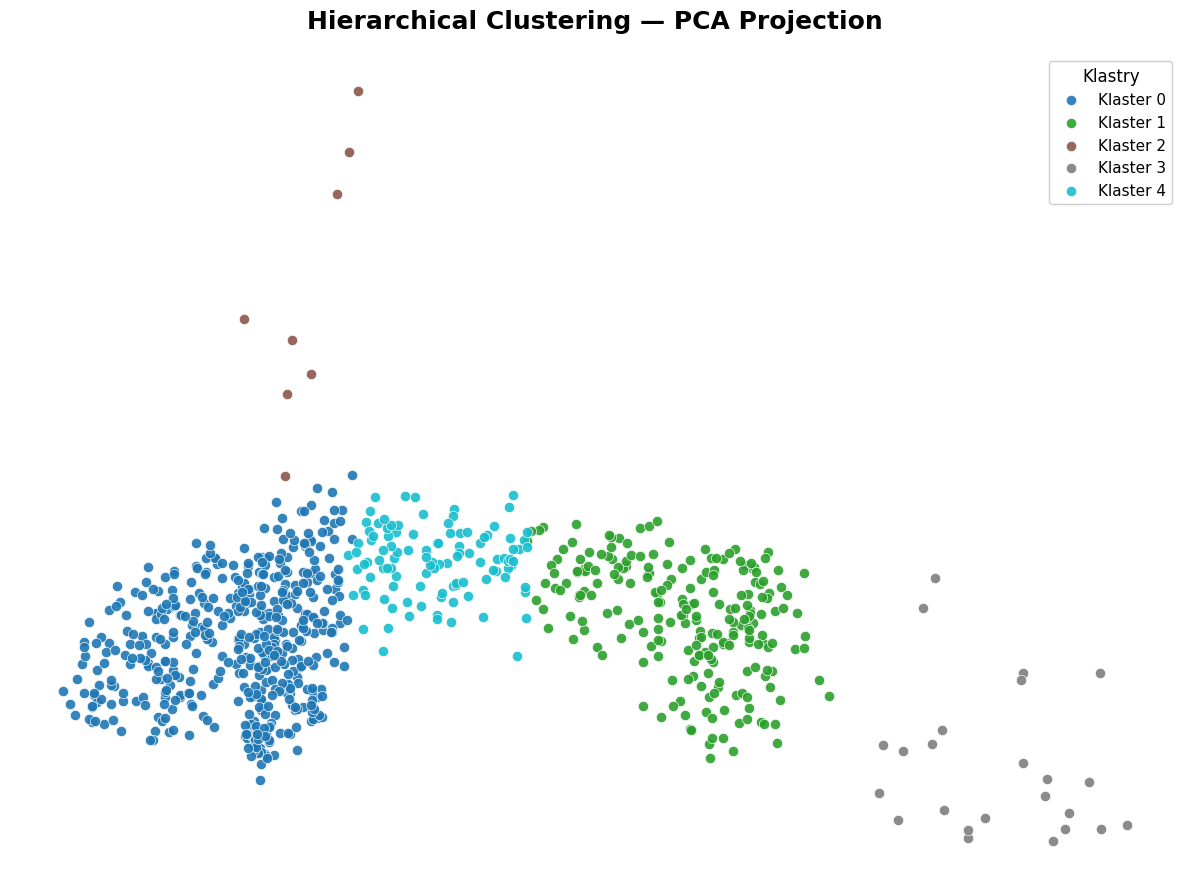

In [ ]:


X_train = import_data('dane/data_18D.txt')
X_train = np.array(X_train)

clusters = hierarchical_divide(X_train, 5)

cluster_labels = np.empty(len(X_train), dtype=int)

for cluster_id, cluster in enumerate(clusters):

    for point in cluster:

        idx = np.where(np.all(X_train == point, axis=1))[0][0]
        cluster_labels[idx] = cluster_id

embedding = PCA(
    n_components=5,
).fit_transform(X_train)

fig, ax = plt.subplots(figsize=(12, 9))

cmap = plt.get_cmap("tab10", len(clusters))

for i in range(len(clusters)):

    pts = embedding[cluster_labels == i]

    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        s=55,
        color=cmap(i),
        alpha=0.9,
        edgecolors='white',
        linewidths=0.5,
        label=f"Klaster {i}"
    )

    center = pts.mean(axis=0)

ax.set_title(
    "Hierarchical Clustering — PCA Projection",
    fontsize=18,
    weight='bold',
    pad=18
)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    fontsize=11,
    title="Klastry",
    title_fontsize=12
)

plt.tight_layout()

plt.savefig(
    "wykres_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Łączenie klastrów: 200 -> 199
Łączenie klastrów: 150 -> 149
Łączenie klastrów: 100 -> 99
Łączenie klastrów: 50 -> 49


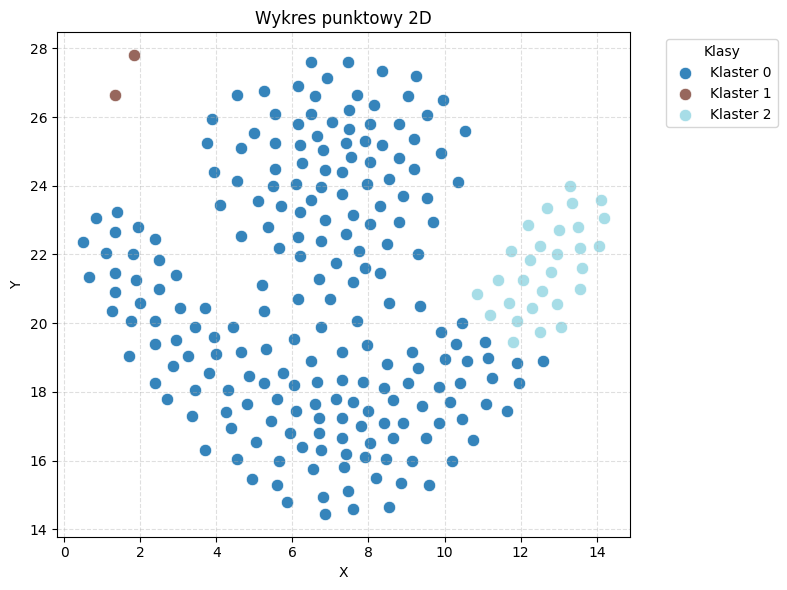

In [30]:

X_train = import_data('dane/dane_2D_8.txt')
X_train = np.array(X_train)
X = X_train[:, :-1]
X = np.random.permutation(X) 
clusters = hierarchical_divide(X, 3)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.get_cmap("tab20", len(clusters))

for i, cluster in enumerate(clusters):
    ax.scatter(
        cluster[:, 0],
        cluster[:, 1],
        c=[colors(i)],
        label=f"Klaster {i}",
        s=80,
        edgecolors="white",
        linewidths=0.6,
        alpha=0.9,
    )


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Wykres punktowy 2D")
ax.legend(title="Klasy", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("wykres.png", dpi=150, bbox_inches="tight")
plt.show()

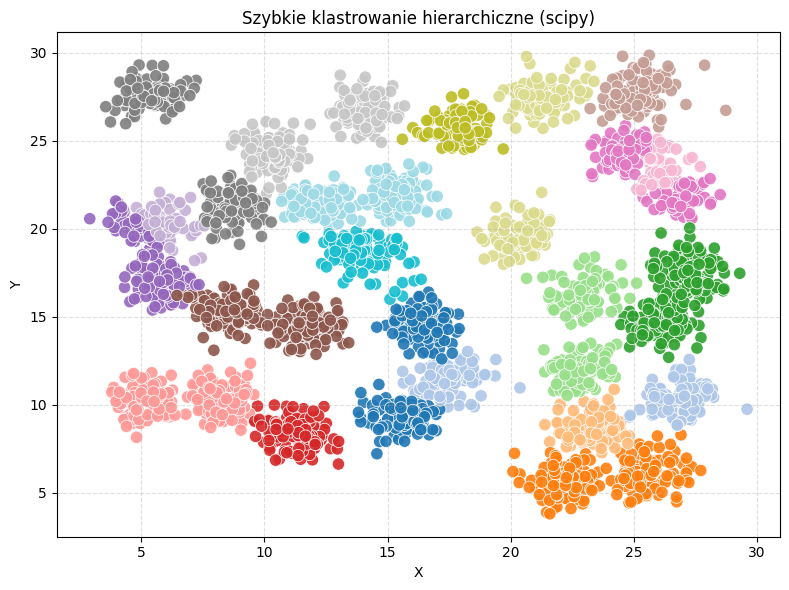

In [27]:
# Szybkie klastrowanie hierarchiczne z scipy
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# Wczytaj dane
X_train = import_data('dane/dane_2D_5.txt')
X_train = np.array(X_train)
X = X_train[:, :-1]
# linkage: metoda 'ward' jest szybka i popularna
Z = linkage(X, method='ward')
# Tworzenie etykiet klastrów (np. 7 klastrów)
labels = fcluster(Z, 35, criterion='maxclust')
# Wizualizacja (np. 2D, jeśli dane są 2D)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab20', s=80, edgecolors='white', linewidths=0.6, alpha=0.9)
plt.title('Szybkie klastrowanie hierarchiczne (scipy)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()